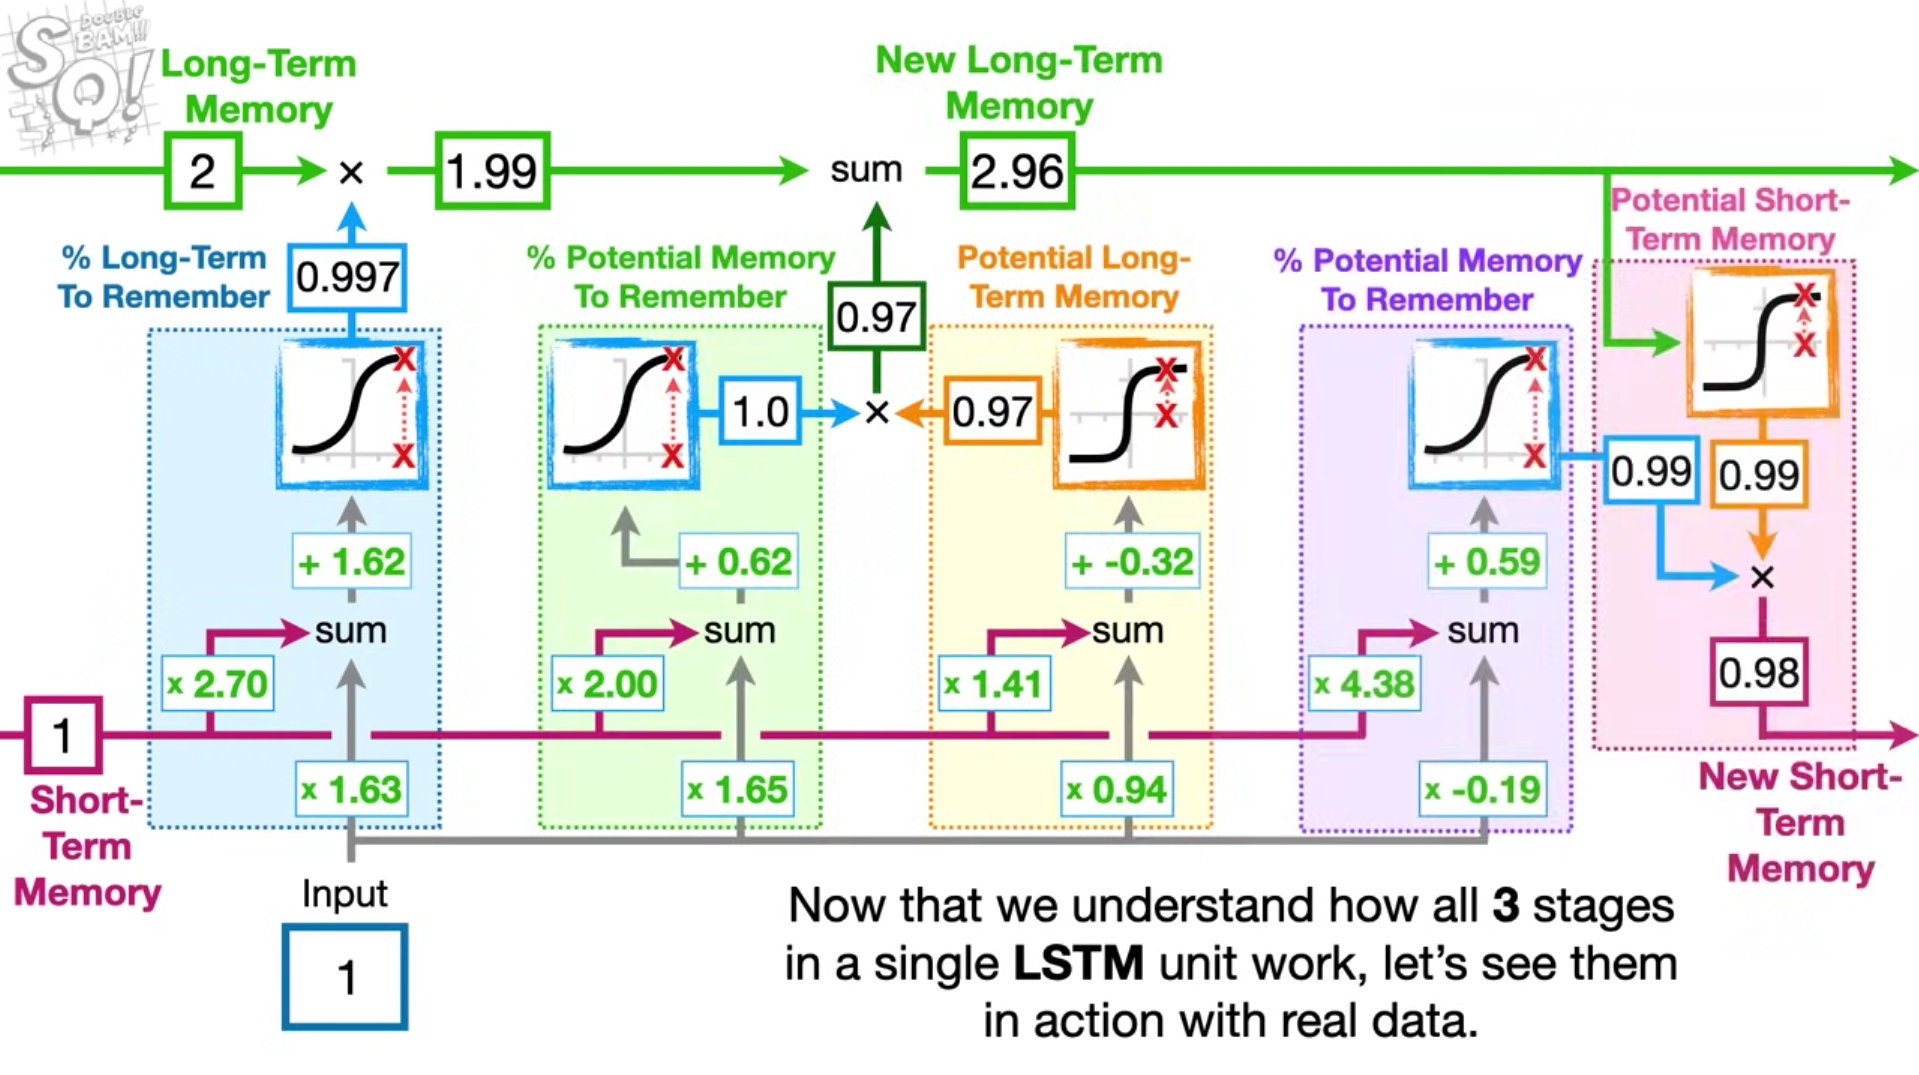

In [1]:
%pip install datasets

In [2]:
from datasets import load_dataset
ds = load_dataset("roneneldan/TinyStories", split="train[:1%]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [3]:
print(ds[0:5])

{'text': ['One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.', 'Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.\n\nOne day, Beep was driving in the park when he saw a big tree. The tree had many leaves

In [4]:
print(len(ds))

21197


In [5]:
with open("tinystories.txt", "w") as f:
    for example in ds:
        f.write(example["text"] + "\n")

In [6]:
with open("tinystories.txt", "r", encoding="utf-8") as f:
    stories = f.read().lower().split("\n")

In [7]:
stories = [s.strip() for s in stories if s.strip()]

In [8]:
print(len(stories))

112894


In [9]:
stories = [example["text"].lower() for example in ds]

In [11]:
print(stories[2])

one day, a little fish named fin was swimming near the shore. he saw a big crab and wanted to be friends. "hi, i am fin. do you want to play?" asked the little fish. the crab looked at fin and said, "no, i don't want to play. i am cold and i don't feel fine."

fin felt sad but wanted to help the crab feel better. he swam away and thought of a plan. he remembered that the sun could make things warm. so, fin swam to the top of the water and called to the sun, "please, sun, help my new friend feel fine and not freeze!"

the sun heard fin's call and shone its warm light on the shore. the crab started to feel better and not so cold. he saw fin and said, "thank you, little fish, for making me feel fine. i don't feel like i will freeze now. let's play together!" and so, fin and the crab played and became good friends.


In [10]:
import re

def tokenize(text):
    return re.findall(r"\b\w+\b|[.,!?;]", text)

In [12]:
print(tokenize("hello, world!"))

['hello', ',', 'world', '!']


In [13]:
tokenized_stories = [tokenize(story) for story in stories]

In [14]:
print(tokenized_stories[0])

['one', 'day', ',', 'a', 'little', 'girl', 'named', 'lily', 'found', 'a', 'needle', 'in', 'her', 'room', '.', 'she', 'knew', 'it', 'was', 'difficult', 'to', 'play', 'with', 'it', 'because', 'it', 'was', 'sharp', '.', 'lily', 'wanted', 'to', 'share', 'the', 'needle', 'with', 'her', 'mom', ',', 'so', 'she', 'could', 'sew', 'a', 'button', 'on', 'her', 'shirt', '.', 'lily', 'went', 'to', 'her', 'mom', 'and', 'said', ',', 'mom', ',', 'i', 'found', 'this', 'needle', '.', 'can', 'you', 'share', 'it', 'with', 'me', 'and', 'sew', 'my', 'shirt', '?', 'her', 'mom', 'smiled', 'and', 'said', ',', 'yes', ',', 'lily', ',', 'we', 'can', 'share', 'the', 'needle', 'and', 'fix', 'your', 'shirt', '.', 'together', ',', 'they', 'shared', 'the', 'needle', 'and', 'sewed', 'the', 'button', 'on', 'lily', 's', 'shirt', '.', 'it', 'was', 'not', 'difficult', 'for', 'them', 'because', 'they', 'were', 'sharing', 'and', 'helping', 'each', 'other', '.', 'after', 'they', 'finished', ',', 'lily', 'thanked', 'her', 'mom'

In [15]:
print(len(tokenized_stories))

21197


In [16]:
all_tokens = []

for story in tokenized_stories:
    for token in story:
        all_tokens.append(token)

In [17]:
vocab = sorted(set(all_tokens))

In [18]:
print(len(vocab))   # vocabulary size
print(vocab[:20])

11512
['!', ',', '.', '00', '1', '10', '100', '10th', '12', '123', '15', '16', '164', '2', '20', '200', '20kg', '25', '29', '3']


In [19]:
special_tokens = ["<PAD>", "<UNK>", "<START>", "<END>"]

vocab = special_tokens + vocab

In [20]:
word2idx = {word: idx for idx, word in enumerate(vocab)}

In [21]:
idx2word = {idx: word for word, idx in word2idx.items()}

In [22]:
print("Vocabulary size:", len(vocab))
print(word2idx["fish"])     # example
print(idx2word[100])         # example

Vocabulary size: 11516
3447
acorns


In [23]:
encoded_stories = []

for story in tokenized_stories:
    encoded_story = [
        word2idx.get(token, word2idx["<UNK>"])
        for token in story
    ]
    encoded_stories.append(encoded_story)

In [24]:
print(tokenized_stories[0][:10])
print(encoded_stories[0][:10])

['one', 'day', ',', 'a', 'little', 'girl', 'named', 'lily', 'found', 'a']
[6449, 2423, 5, 44, 5427, 3903, 6155, 5384, 3679, 44]


In [25]:
start_id = word2idx["<START>"]
end_id = word2idx["<END>"]

encoded_stories = [
    [start_id] + story + [end_id]
    for story in encoded_stories
]

In [26]:
import torch

encoded_stories = [
    torch.tensor(story, dtype=torch.long)
    for story in encoded_stories
]

In [27]:
X = []
y = []
seq_length = 6
for story in encoded_stories:


    if len(story) <= seq_length:
        continue

    for i in range(len(story) - seq_length):
        input_seq = story[i:i+seq_length]
        target = story[i+seq_length]

        X.append(input_seq)
        y.append(target)

In [28]:
print(X[0:5])
print(y[0:5])

[tensor([   2, 6449, 2423,    5,   44, 5427]), tensor([6449, 2423,    5,   44, 5427, 3903]), tensor([2423,    5,   44, 5427, 3903, 6155]), tensor([   5,   44, 5427, 3903, 6155, 5384]), tensor([  44, 5427, 3903, 6155, 5384, 3679])]
[tensor(3903), tensor(6155), tensor(5384), tensor(3679), tensor(44)]


In [29]:
X = torch.stack(X)
y = torch.tensor(y, dtype=torch.long)

In [30]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([4263456, 6])
y shape: torch.Size([4263456])


In [31]:
from torch.utils.data import Dataset
class StoryDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [32]:
dataset = StoryDataset(X, y)

In [33]:
print(len(dataset))
print(dataset[0])

4263456
(tensor([   2, 6449, 2423,    5,   44, 5427]), tensor(3903))


In [34]:
from torch.utils.data import DataLoader

batch_size = 64

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

In [35]:
for batch_X, batch_y in dataloader:
    print(batch_X.shape)
    print(batch_y.shape)
    break

torch.Size([64, 6])
torch.Size([64])


In [37]:
import torch.nn as nn

In [38]:
class StoryLSTM(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):

        x = self.embedding(x)


        output, (hidden, cell) = self.lstm(x)

        output = output[:, -1, :]
        output = self.fc(output)

        return output

In [39]:
vocab_size = len(vocab)

model = StoryLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_size=256
)

In [40]:
sample_batch, _ = next(iter(dataloader))

output = model(sample_batch)

print(output.shape)

torch.Size([64, 11516])


In [41]:
criterion = nn.CrossEntropyLoss()

In [42]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [44]:
epochs = 10

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch_X, batch_y in dataloader:


        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)


        outputs = model(batch_X)


        loss = criterion(outputs, batch_y)


        optimizer.zero_grad()


        loss.backward()


        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

KeyboardInterrupt: 

In [ ]:
import torch.nn.functional as F

def generate_story(model, start_text, max_length=50, temperature=1.0):

    model.eval()

    # Tokenize input text
    tokens = tokenize(start_text.lower())

    # Convert to indices
    state = [
        word2idx.get(token, word2idx["<UNK>"])
        for token in tokens
    ]

    # Add <START> token
    state = [word2idx["<START>"]] + state

    for _ in range(max_length):

        # Take last seq_length tokens
        input_seq = state[-seq_length:]

        # Pad if too short
        if len(input_seq) < seq_length:
            input_seq = [word2idx["<PAD>"]] * (seq_length - len(input_seq)) + input_seq

        input_tensor = torch.tensor([input_seq], dtype=torch.long).to(device)

        with torch.no_grad():
            output = model(input_tensor)

        # Convert scores to probabilities
        probs = F.softmax(output / temperature, dim=1)

        # Sample next word
        next_token = torch.multinomial(probs, num_samples=1).item()

        # Stop if <END>
        if next_token == word2idx["<END>"]:
            break

        state.append(next_token)

    # Convert indices back to words
    generated_tokens = [idx2word[idx] for idx in state]

    # Remove special tokens
    generated_tokens = [
        token for token in generated_tokens
        if token not in ["<START>", "<PAD>"]
    ]

    return " ".join(generated_tokens)

In [ ]:
print(generate_story(model, "once upon a time"))